
# Overplotting field lines on AIA maps

This example shows how to take a PFSS solution, trace some field lines, and
overplot the traced field lines on an AIA 193 map.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
from astropy.coordinates import SkyCoord

import sunpy.map

import sunkit_magex.pfss
import sunkit_magex.pfss.tracing as tracing
from sunkit_magex.pfss.sample_data import get_gong_map

Load a GONG magnetic field map.



In [3]:
gong_fname = get_gong_map()
gong_map = sunpy.map.Map(gong_fname)

Load the corresponding AIA 193 map.



In [4]:
aia_map = sunpy.map.Map('http://jsoc.stanford.edu/data/aia/synoptic/2020/09/01/H1300/AIA20200901_1300_0193.fits')

Files Downloaded: 100%|██████████| 1/1 [00:02<00:00,  2.56s/file]


The PFSS solution is calculated on a regular 3D grid in (phi, s, rho), where
rho = ln(r), and r is the standard spherical radial coordinate. We need to
define the number of grid points in rho, and the source surface radius.



In [5]:
nrho = 25
rss = 2.5

From the boundary condition, number of radial grid points, and source
surface, we now construct an `~sunkit_magex.pfss.Input` object that stores this information.



In [8]:
pfss_in = sunkit_magex.pfss.Input(gong_map, nrho, rss)

We can also plot the AIA map to give an idea of the global picture. There
is a nice active region in the top right of the AIA plot, that can also
be seen in the top left of the photospheric field plot above.

We construct a 5 x 5 grid of footpoints to trace some magnetic field
lines from. These coordinates are defined in the helioprojective frame of the
AIA image.



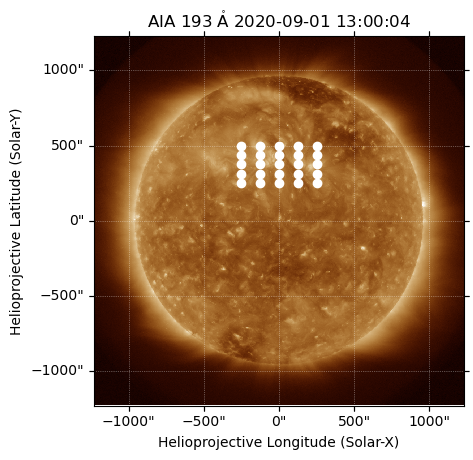

In [9]:
hp_lon = np.linspace(-250, 250, 5) * u.arcsec
hp_lat = np.linspace(250, 500, 5) * u.arcsec
# Make a 2D grid from these 1D points
lon, lat = np.meshgrid(hp_lon, hp_lat)
seeds = SkyCoord(lon.ravel(), lat.ravel(), frame=aia_map.coordinate_frame)

fig = plt.figure()
ax = fig.add_subplot(projection=aia_map)

aia_map.plot(axes=ax)
ax.plot_coord(seeds, color='white', marker='o', linewidth=0)

Using the `~sunkit_magex.pfss.Input` object, we can plot the input photospheric
magnetic field and the seed footpoints The footpoints are centered
around the active region mentioned above.



INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


(0.0, 179.5)

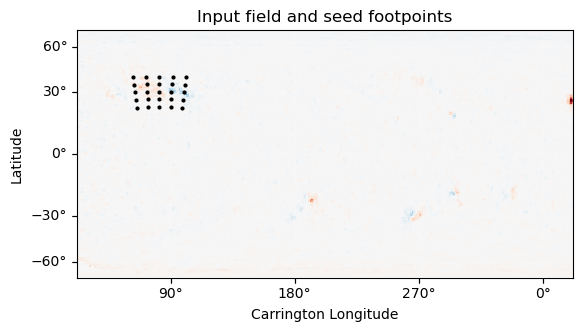

In [14]:
input_map = pfss_in.map

fig = plt.figure()
ax = fig.add_subplot(projection=input_map)
input_map.plot(axes=ax)
ax.plot_coord(seeds, color='black', marker='o', linewidth=0, markersize=2)

# plt.colorbar()
ax.set_title('Input field and seed footpoints')
ax.set_ylim(bottom=0)

Compute the PFSS solution from the GONG magnetic field input.



In [11]:
pfss_out = sunkit_magex.pfss.pfss(pfss_in)

Trace field lines from the footpoints defined above.



In [12]:
tracer = tracing.PerformanceTracer()
flines = tracer.trace(seeds, pfss_out)

/Users/xwu/opt/miniconda3/envs/sunpy_7/lib/python3.13/site-packages/sunkit_magex/pfss/tracing.py:176: UserWarning: At least one field line ran out of steps during tracing.
You should probably increase max_steps (currently set to auto) and try again.
  warnings.warn(


Plot the input GONG magnetic field map, along with the traced magnetic field
lines.



Text(0.5, 1.0, 'Photospheric field and traced field lines')

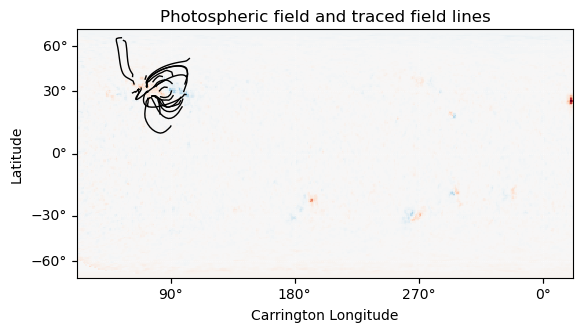

In [14]:
fig = plt.figure()
ax = fig.add_subplot(projection=input_map)

input_map.plot(axes=ax)
# plt.colorbar()
for fline in flines:
    ax.plot_coord(fline.coords, color='black', linewidth=1)
ax.set_title('Photospheric field and traced field lines')

Plot the AIA map, along with the traced magnetic field lines. Inside the
loop the field lines are converted to the AIA observer coordinate frame,
and then plotted on top of the map.



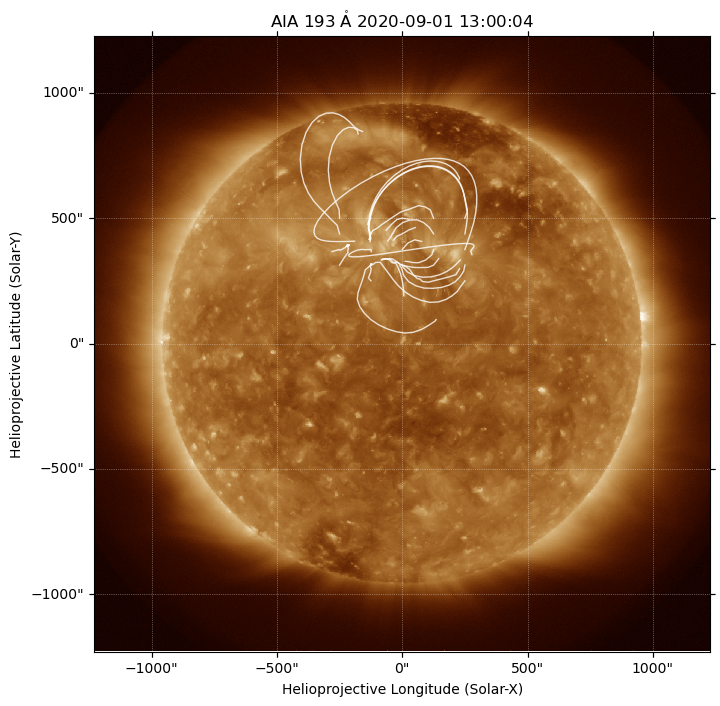

In [17]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1, projection=aia_map)
aia_map.plot(axes=ax)
for fline in flines:
    ax.plot_coord(fline.coords, alpha=0.8, linewidth=1, color='white')

plt.show()